# Baseline Sentiment Analysis (DistilBERT)

This notebook provides a quick analysis of the baseline sentiment results obtained
from DistilBERT on the ESG corpus. The goal is to evaluate the raw output distribution
before applying snippet and lexicon-based enhancements.

The following visualizations are included:
1. Sentiment distribution by company
2. Sentiment distribution by year

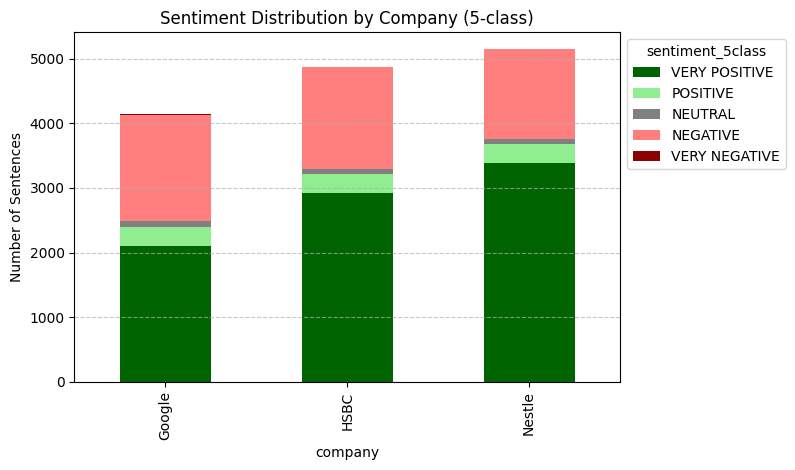

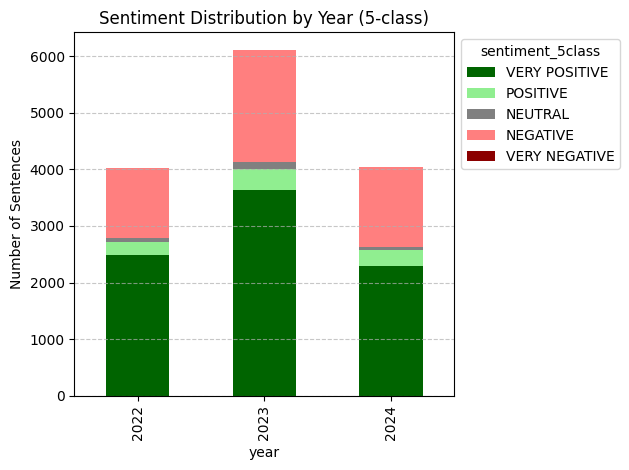

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the 5-class dataset
df = pd.read_csv("../data/processed/distilbert_baseline_5class.csv")

# Class order and color palette
class_order = ["VERY POSITIVE", "POSITIVE", "NEUTRAL", "NEGATIVE", "VERY NEGATIVE"]
colors = {
    "VERY POSITIVE": "#006400",    # dark green
    "POSITIVE": "#90EE90",         # light green
    "NEUTRAL": "#808080",          # grey
    "NEGATIVE": "#FF7F7F",         # light red
    "VERY NEGATIVE": "#8B0000"     # dark red
}

# 2) Company-level distribution
company_counts = df.groupby("company")['sentiment_5class'].value_counts().unstack().reindex(columns=class_order)
company_counts.plot(kind="bar", stacked=True, color=[colors[c] for c in class_order])
plt.title("Sentiment Distribution by Company (5-class)")
plt.ylabel("Number of Sentences")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.legend(title="sentiment_5class", bbox_to_anchor=(1.00, 1), loc='upper left')
plt.savefig("../images/company_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# 3) Year-level distribution
year_counts = df.groupby("year")['sentiment_5class'].value_counts().unstack().reindex(columns=class_order)
year_counts.plot(kind="bar", stacked=True, color=[colors[c] for c in class_order])
plt.title("Sentiment Distribution by Year (5-class)")
plt.ylabel("Number of Sentences")
plt.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.legend(title="sentiment_5class", bbox_to_anchor=(1.00, 1), loc='upper left')
plt.tight_layout()
plt.savefig("../images/year_distribution.png", dpi=300)
plt.show()

**Observation:**  
DistilBERT baseline results reveal a strong positive bias across all companies and years.  
This underlines the need for domain-specific enhancements (lexicons, negation handling, intensifier detection),  
which will be addressed in the next stage of the pipeline.
